# Entrenamiento de Modelo Multimodal (Fusión Temprana)
## Predicción de Autismo basado en Resonancia Magnética (MRI)

---

**Objetivo:** Entrenar un modelo **Perceptrón Multicapa (MLP)** que reciba como entrada los embeddings pre-computados (256-d) de los tres planos anatómicos (Sagital, Coronal, Axial) de un mismo paciente. El modelo aprenderá la interacción cruzada de las vistas para emitir la predicción final de riesgo (Autism o NonAutism).

> **Mejoras aplicadas:** Utilizamos concatenación plana (fusión temprana, $256 \times 3 = 768$ dimensiones) y `BCEWithLogitsLoss` para mayor estabilidad numérica sin recurrir a sigmoid en las variables intermedias. También evaluamos una Variante A (más ligera) contra arquitecturas más profundas.


---
## 1. Importación de Librerías y Constantes

In [1]:
import os
import copy
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# === CONSTANTES PRINCIPALES ===
BASE_DIR = Path('../').resolve()
EMBEDDINGS_DIR = BASE_DIR / 'data' / 'embeddings'
MODELS_DIR     = BASE_DIR / 'models' / 'multimodal'
RESULTS_DIR    = BASE_DIR / 'results'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SLICE_TYPES = ['sagittal', 'coronal', 'axial']
SPLITS = ['train', 'val', 'test']
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Device: {DEVICE}')

Device: cuda


---
## 2. Carga y Procesamiento de Embeddings a Nivel Paciente

In [2]:
def load_and_aggregate_embeddings(split):
    """
    Carga embeddings .npz guardados para `split`, agrupa por paciente,
    promedia todos los cortes de cada vista, y devuelve [X, Y, patient_ids].
    X = concat(mean_sag, mean_cor, mean_axi) -> 768-d.
    """
    patients_data = {}
    
    for stype in SLICE_TYPES:
        npz_path = EMBEDDINGS_DIR / f'{stype}_{split}.npz'
        data = np.load(npz_path)
        embs = data['embeddings']
        labels = data['labels']
        pids = data['patient_ids']
        
        for i in range(len(pids)):
            pid = str(pids[i])
            if pid not in patients_data:
                patients_data[pid] = {'sagittal': [], 'coronal': [], 'axial': [], 'label': int(labels[i])}
            patients_data[pid][stype].append(embs[i])
            
    X_list, y_list, p_list = [], [], []
    for pid, data in patients_data.items():
        # Intersección Estricta: Nos aseguramos de que el paciente tenga los 3 planos.
        if len(data['sagittal']) > 0 and len(data['coronal']) > 0 and len(data['axial']) > 0:
            mean_sag = np.mean(data['sagittal'], axis=0) # 256-d
            mean_cor = np.mean(data['coronal'], axis=0)  # 256-d
            mean_axi = np.mean(data['axial'], axis=0)    # 256-d
            
            # Fusión Temprana
            multimodal_emb = np.concatenate([mean_sag, mean_cor, mean_axi]) # 768-d
            
            X_list.append(multimodal_emb)
            y_list.append(data['label'])
            p_list.append(pid)
            
    return np.array(X_list), np.array(y_list), p_list

print("Generando datasets fusionados a nivel paciente...")
X_train, y_train, p_train = load_and_aggregate_embeddings('train')
X_val, y_val, p_val = load_and_aggregate_embeddings('val')
X_test, y_test, p_test = load_and_aggregate_embeddings('test')

print(f"Train: {X_train.shape}, Y: {y_train.shape} (Positivos: {y_train.sum()})")
print(f"Val:   {X_val.shape}, Y: {y_val.shape} (Positivos: {y_val.sum()})")
print(f"Test:  {X_test.shape}, Y: {y_test.shape} (Positivos: {y_test.sum()})")


Generando datasets fusionados a nivel paciente...
Train: (1361, 768), Y: (1361,) (Positivos: 668)
Val:   (292, 768), Y: (292,) (Positivos: 143)
Test:  (292, 768), Y: (292,) (Positivos: 144)


---
## 3. Preparación de PyTorch Dataset & DataLoader

In [3]:
class MultimodalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Batch size puede ser grande ya que son vectores puros en CPU/GPU sin procesar imágenes densas
ds_train = MultimodalDataset(X_train, y_train)
ds_val   = MultimodalDataset(X_val, y_val)
ds_test  = MultimodalDataset(X_test, y_test)

dl_train = DataLoader(ds_train, batch_size=32, shuffle=True)
dl_val   = DataLoader(ds_val, batch_size=32, shuffle=False)
dl_test  = DataLoader(ds_test, batch_size=32, shuffle=False)


---
## 4. Definición de Arquitectura (Variantes)

In [4]:
class VariantA(nn.Module):
    """ Arquitectura Base: 1 Capa Oculta, sin BatchNorm, Drop 0.5 """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(768, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1) # Sin Sigmoid por usar BCEWithLogitsLoss
        )
    def forward(self, x):
        return self.net(x)

class VariantB(nn.Module):
    """ 1 Capa Oculta, con BatchNorm """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(768, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x)

class VariantC(nn.Module):
    """ 2 Capas Ocultas """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(768, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)


---
## 5. Bucle de Entrenamiento (con BCEWithLogitsLoss)

In [5]:
def train_multimodal(model_class, variant_name, epochs=30):
    model = model_class().to(DEVICE)
    
    # Class weighting
    class_counts = np.bincount(y_train)
    pos_weight_val = class_counts[0] / class_counts[1]
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_val]).to(DEVICE))
    
    # L2 Regularization (weight_decay)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
    
    best_val_auc = 0.0
    best_weights = None
    patience = 12
    epochs_no_improve = 0
    
    print(f"\n{'='*50}")
    print(f" ENTRENANDO: {variant_name}")
    print(f"{'='*50}")
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        all_y, all_p = [], []
        
        for xb, yb in dl_train:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb).squeeze(1)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * len(xb)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_y.extend(yb.cpu().numpy())
            all_p.extend(probs)
            
        train_loss /= len(dl_train.dataset)
        train_auc = roc_auc_score(all_y, all_p)
        
        # --- VALIDACION ---
        model.eval()
        val_loss = 0
        all_y_val, all_p_val = [], []
        
        with torch.no_grad():
            for xb, yb in dl_val:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb).squeeze(1)
                loss = criterion(logits, yb)
                val_loss += loss.item() * len(xb)
                
                probs = torch.sigmoid(logits).cpu().numpy()
                all_y_val.extend(yb.cpu().numpy())
                all_p_val.extend(probs)
                
        val_loss /= len(dl_val.dataset)
        val_auc = roc_auc_score(all_y_val, all_p_val)
        
        if epoch % 5 == 0 or epoch == epochs - 1:
            print(f"Ep {epoch+1:02d} | T-Loss: {train_loss:.4f} T-AUC: {train_auc:.4f} || V-Loss: {val_loss:.4f} V-AUC: {val_auc:.4f}")
            
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\n[!] Early Stopping en época {epoch+1}. Mejor Val AUC: {best_val_auc:.4f}")
                break
                
    model.load_state_dict(best_weights)
    return model, best_val_auc


---
## 6. Ejecución y Selección del Mejor Modelo

In [6]:
m_A, auc_A = train_multimodal(VariantA, "Variante A (1 capa oculta, sin BN)")
m_B, auc_B = train_multimodal(VariantB, "Variante B (1 capa oculta, con BN)")
m_C, auc_C = train_multimodal(VariantC, "Variante C (2 capas ocultas)")

print("\n--- RESULTADOS VALIDACIÓN ---")
print(f"Variante A AUC: {auc_A:.4f}")
print(f"Variante B AUC: {auc_B:.4f}")
print(f"Variante C AUC: {auc_C:.4f}")

variants = {'VariantA': (m_A, auc_A), 'VariantB': (m_B, auc_B), 'VariantC': (m_C, auc_C)}
best_name = max(variants.items(), key=lambda x: x[1][1])[0]
best_model = variants[best_name][0]

print(f"\nSeleccionada la arquitectura: {best_name}")

# Guardar el modelo multimodal entrenado
MULTIMODAL_PATH = MODELS_DIR / 'multimodal_best.pt'
torch.save(best_model.state_dict(), MULTIMODAL_PATH)
print(f"Modelo multimodal guardado en: {MULTIMODAL_PATH}")



 ENTRENANDO: Variante A (1 capa oculta, sin BN)
Ep 01 | T-Loss: 0.4989 T-AUC: 0.8806 || V-Loss: 0.8329 V-AUC: 0.6402
Ep 06 | T-Loss: 0.1568 T-AUC: 0.9869 || V-Loss: 1.3382 V-AUC: 0.6217
Ep 11 | T-Loss: 0.1137 T-AUC: 0.9932 || V-Loss: 1.6249 V-AUC: 0.6060

[!] Early Stopping en época 14. Mejor Val AUC: 0.6422

 ENTRENANDO: Variante B (1 capa oculta, con BN)
Ep 01 | T-Loss: 0.3545 T-AUC: 0.9349 || V-Loss: 0.9544 V-AUC: 0.6354
Ep 06 | T-Loss: 0.0951 T-AUC: 0.9967 || V-Loss: 1.5952 V-AUC: 0.6007
Ep 11 | T-Loss: 0.0489 T-AUC: 0.9995 || V-Loss: 1.9486 V-AUC: 0.5763

[!] Early Stopping en época 13. Mejor Val AUC: 0.6354

 ENTRENANDO: Variante C (2 capas ocultas)
Ep 01 | T-Loss: 0.5557 T-AUC: 0.8489 || V-Loss: 0.8135 V-AUC: 0.6443
Ep 06 | T-Loss: 0.1746 T-AUC: 0.9820 || V-Loss: 1.4585 V-AUC: 0.6246
Ep 11 | T-Loss: 0.0875 T-AUC: 0.9959 || V-Loss: 2.0484 V-AUC: 0.5991

[!] Early Stopping en época 13. Mejor Val AUC: 0.6443

--- RESULTADOS VALIDACIÓN ---
Variante A AUC: 0.6422
Variante B AUC: 0.6

---
## 7. Evaluación Final en TEST SET

In [7]:
best_model.eval()
all_y_test, all_p_test = [], []

with torch.no_grad():
    for xb, yb in dl_test:
        xb = xb.to(DEVICE)
        logits = best_model(xb).squeeze(1)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_y_test.extend(yb.numpy())
        all_p_test.extend(probs)

y_true = np.array(all_y_test)
y_proba = np.array(all_p_test)
y_pred = (y_proba >= 0.5).astype(int)

metricas = {
    'AUC': roc_auc_score(y_true, y_proba),
    'Accuracy': accuracy_score(y_true, y_pred),
    'F1': f1_score(y_true, y_pred, average="macro"),
    'Precision': precision_score(y_true, y_pred, average="macro"),
    'Recall': recall_score(y_true, y_pred, average="macro")
}

print(f"\n=== MÉTRICAS TEST (MULTIMODAL - {best_name}) ===")
for k, v in metricas.items():
    print(f"{k:<12}: {v:.4f}")



=== MÉTRICAS TEST (MULTIMODAL - VariantC) ===
AUC         : 0.6761
Accuracy    : 0.5993
F1          : 0.5993
Precision   : 0.5997
Recall      : 0.5996


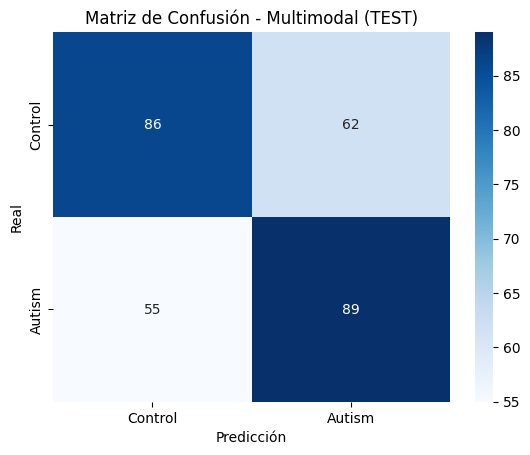

In [ ]:
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Control', 'Autism'], yticklabels=['Control', 'Autism'])
plt.title("Matriz de Confusión - Multimodal (TEST)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()